##### 🧪 EXPERIMENT–3 Variation of Training Ratio with Fixed Dataset Size Gesture + Person Identification (Joint Classification)

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [43]:
df = pd.read_csv("hand_gesture_final_ready.csv")
print(df.shape)
print(df.columns)


(5226, 215)
Index(['dist_0_1', 'dist_0_2', 'dist_0_3', 'dist_0_4', 'dist_0_5', 'dist_0_6',
       'dist_0_7', 'dist_0_8', 'dist_0_9', 'dist_0_10',
       ...
       'dist_17_19', 'dist_17_20', 'dist_18_19', 'dist_18_20', 'dist_19_20',
       'person_id', 'person_name', 'gesture', 'gesture_label', 'output_label'],
      dtype='object', length=215)


In [44]:
# Feature columns
feature_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[feature_cols]

# Labels
gesture = df["gesture_label"].values
person  = df["person_id"].values


In [ ]:
# Encode joint label as string first
joint_label = np.array(
    [f"{g}_{p}" for g, p in zip(gesture, person)]
)

# Encode to integers
le_joint = LabelEncoder()
y_joint = le_joint.fit_transform(joint_label)

print("Total joint classes:", len(np.unique(y_joint)))

Total joint classes: 506


In [46]:
def get_models():
    return {
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(kernel="rbf"),
        "XGBoost": XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            verbosity=0
        )
    }


In [47]:
train_ratios = [0.5, 0.6, 0.7, 0.8]
results_exp3 = []

for ratio in train_ratios:

    splitter = StratifiedShuffleSplit(
        n_splits=5,
        train_size=ratio,
        random_state=42
    )

    for train_idx, test_idx in splitter.split(X, y_joint):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_joint[train_idx], y_joint[test_idx]

        # Scalers
        std_scaler = StandardScaler().fit(X_train)
        mm_scaler  = MinMaxScaler().fit(X_train)

        for name, model in get_models().items():

            if name in ["Logistic Regression", "SVM", "KNN"]:
                X_tr = std_scaler.transform(X_train)
                X_te = std_scaler.transform(X_test)
            else:
                X_tr = mm_scaler.transform(X_train)
                X_te = mm_scaler.transform(X_test)

            model.fit(X_tr, y_train)
            preds = model.predict(X_te)

            results_exp3.append([
                f"{int(ratio*100)}-{100-int(ratio*100)}",
                name,
                accuracy_score(y_test, preds),
                precision_score(y_test, preds, average="weighted", zero_division=0),
                recall_score(y_test, preds, average="weighted"),
                f1_score(y_test, preds, average="weighted")
            ])


In [ ]:
df_exp3 = pd.DataFrame(
    results_exp3,
    columns=["Train Ratio", "Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(df_exp3.head())
print(df_exp3.groupby(["Train Ratio", "Model"]).mean())

  Train Ratio                Model  Accuracy  Precision    Recall  F1-Score
0       50-50          Naive Bayes  0.912744   0.977906  0.912744  0.931820
1       50-50        Decision Tree  0.837734   0.862034  0.837734  0.831464
2       50-50        Random Forest  0.981248   0.984786  0.981248  0.980756
3       50-50                  KNN  0.955607   0.962819  0.955607  0.951955
4       50-50  Logistic Regression  0.979334   0.982782  0.979334  0.978788
                                 Accuracy  Precision    Recall  F1-Score
Train Ratio Model                                                       
50-50       Decision Tree        0.828779   0.853011  0.828779  0.821949
            KNN                  0.958285   0.964123  0.958285  0.954621
            Logistic Regression  0.981860   0.984289  0.981860  0.981079
            Naive Bayes          0.906927   0.973039  0.906927  0.926135
            Random Forest        0.985151   0.987075  0.985151  0.984488
            SVM                  

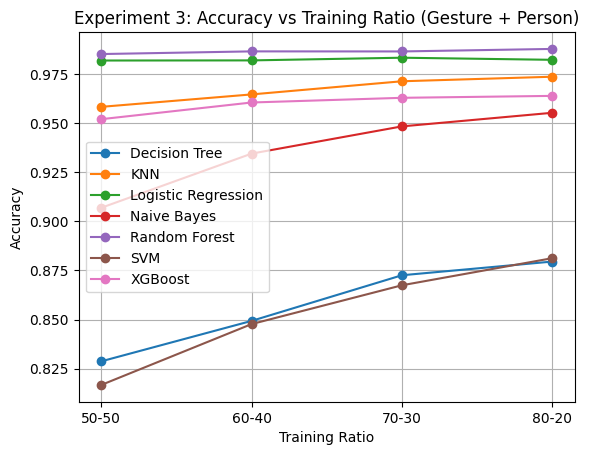

In [49]:
import matplotlib.pyplot as plt

avg_acc = (
    df_exp3
    .groupby(["Train Ratio", "Model"])["Accuracy"]
    .mean()
    .reset_index()
)

plt.figure()
for model in avg_acc["Model"].unique():
    temp = avg_acc[avg_acc["Model"] == model]
    plt.plot(temp["Train Ratio"], temp["Accuracy"], marker='o', label=model)

plt.xlabel("Training Ratio")
plt.ylabel("Accuracy")
plt.title("Experiment 3: Accuracy vs Training Ratio (Gesture + Person)")
plt.legend()
plt.grid(True)
plt.show()


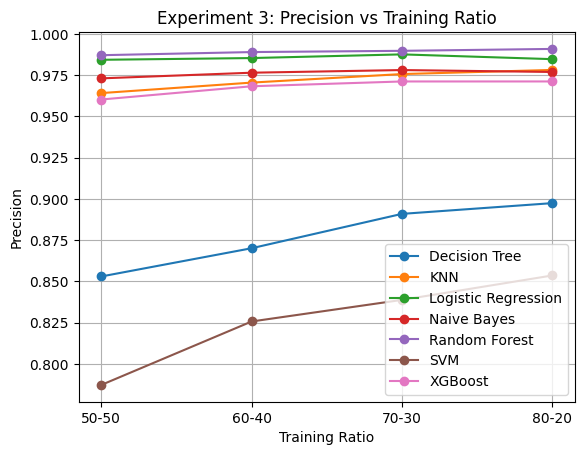

In [50]:
avg_prec = (
    df_exp3
    .groupby(["Train Ratio", "Model"])["Precision"]
    .mean()
    .reset_index()
)

plt.figure()
for model in avg_prec["Model"].unique():
    temp = avg_prec[avg_prec["Model"] == model]
    plt.plot(temp["Train Ratio"], temp["Precision"], marker='o', label=model)

plt.xlabel("Training Ratio")
plt.ylabel("Precision")
plt.title("Experiment 3: Precision vs Training Ratio")
plt.legend()
plt.grid(True)
plt.show()


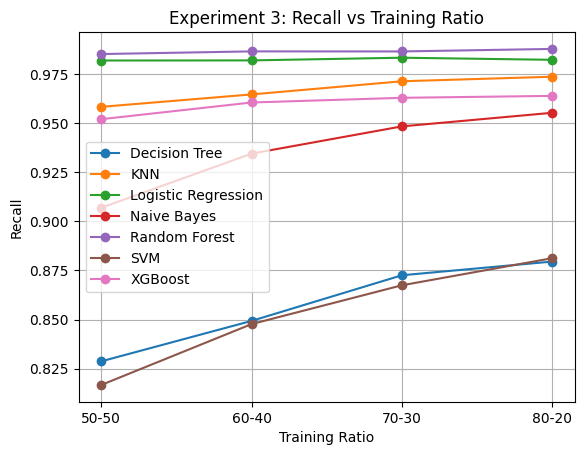

In [51]:
avg_rec = (
    df_exp3
    .groupby(["Train Ratio", "Model"])["Recall"]
    .mean()
    .reset_index()
)

plt.figure()
for model in avg_rec["Model"].unique():
    temp = avg_rec[avg_rec["Model"] == model]
    plt.plot(temp["Train Ratio"], temp["Recall"], marker='o', label=model)

plt.xlabel("Training Ratio")
plt.ylabel("Recall")
plt.title("Experiment 3: Recall vs Training Ratio")
plt.legend()
plt.grid(True)
plt.show()


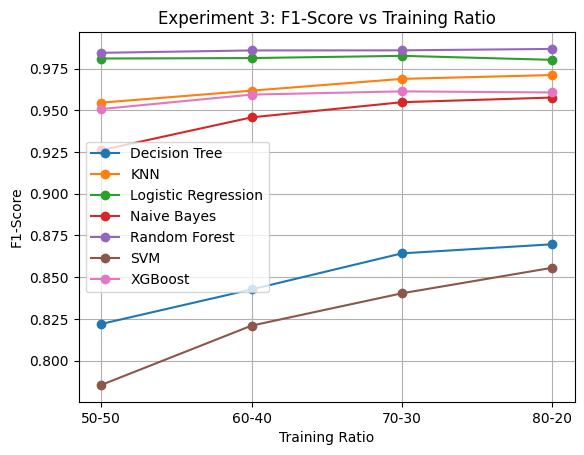

In [52]:
avg_f1 = (
    df_exp3
    .groupby(["Train Ratio", "Model"])["F1-Score"]
    .mean()
    .reset_index()
)

plt.figure()
for model in avg_f1["Model"].unique():
    temp = avg_f1[avg_f1["Model"] == model]
    plt.plot(temp["Train Ratio"], temp["F1-Score"], marker='o', label=model)

plt.xlabel("Training Ratio")
plt.ylabel("F1-Score")
plt.title("Experiment 3: F1-Score vs Training Ratio")
plt.legend()
plt.grid(True)
plt.show()


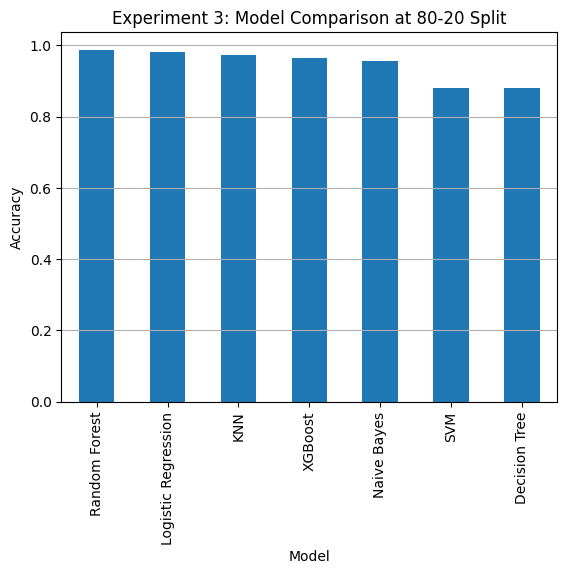

In [53]:
best_8020 = (
    df_exp3[df_exp3["Train Ratio"] == "80-20"]
    .groupby("Model")["Accuracy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
best_8020.plot(kind="bar")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Experiment 3: Model Comparison at 80-20 Split")
plt.grid(axis="y")
plt.show()


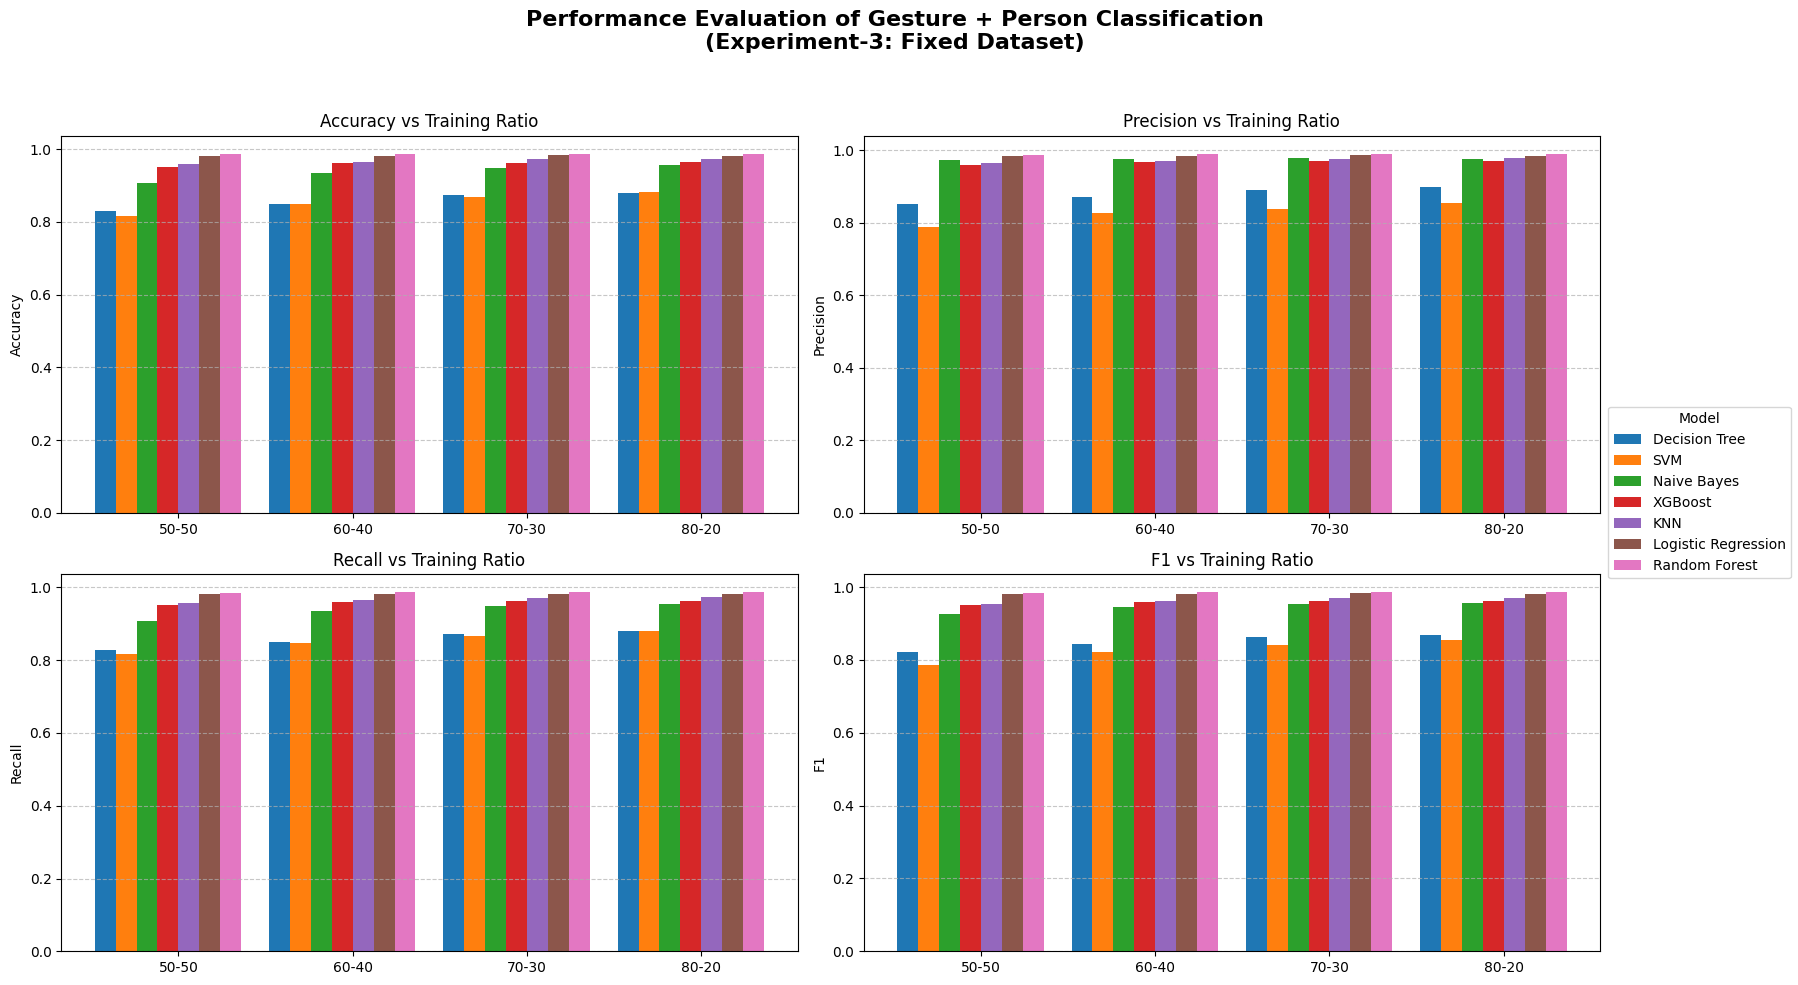

In [56]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
splits =  df_exp3["Train Ratio"].unique()

# FIXED MODEL ORDER
models = [
    "Decision Tree",
    "SVM",
    "Naive Bayes",
    "XGBoost",
    "KNN",
    "Logistic Regression",
    "Random Forest"
]

models = [m for m in models if m in  df_exp3["Model"].unique()]

bar_width = 0.12
x = np.arange(len(splits))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(
    "Performance Evaluation of Gesture + Person Classification\n"
    "(Experiment-3: Fixed Dataset)",
    fontsize=16,
    fontweight="bold"
)

def plot_metric(ax, metric, ylabel, title):
    for i, model in enumerate(models):
        values = []
        for split in splits:
            val =  df_exp3[
                ( df_exp3["Train Ratio"] == split) &
                ( df_exp3["Model"] == model)
            ][metric].mean()
            values.append(val)

        ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            label=model
        )

    ax.set_xticks(x + bar_width * (len(models) / 2))
    ax.set_xticklabels(splits)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plot_metric(axes[0, 0], "Accuracy", "Accuracy", "Accuracy vs Training Ratio")
plot_metric(axes[0, 1], "Precision", "Precision", "Precision vs Training Ratio")
plot_metric(axes[1, 0], "Recall", "Recall", "Recall vs Training Ratio")
plot_metric(axes[1, 1], "F1-Score", "F1", "F1 vs Training Ratio")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    title="Model"
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
model_order = [
    "Decision Tree",
    "SVM",
    "Naive Bayes",
    "XGBoost",
    "KNN",
    "Logistic Regression",
    "Random Forest"
]


In [ ]:
def plot_heatmap(df, metric, title):
    # Pivot table
    heatmap_data = df.pivot_table(
        index="Model",
        columns="Train Ratio",
        values=metric,
        aggfunc="mean"
    )

    # Reorder models
    heatmap_data = heatmap_data.reindex(model_order)

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={"label": metric}
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Training Ratio")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()
    


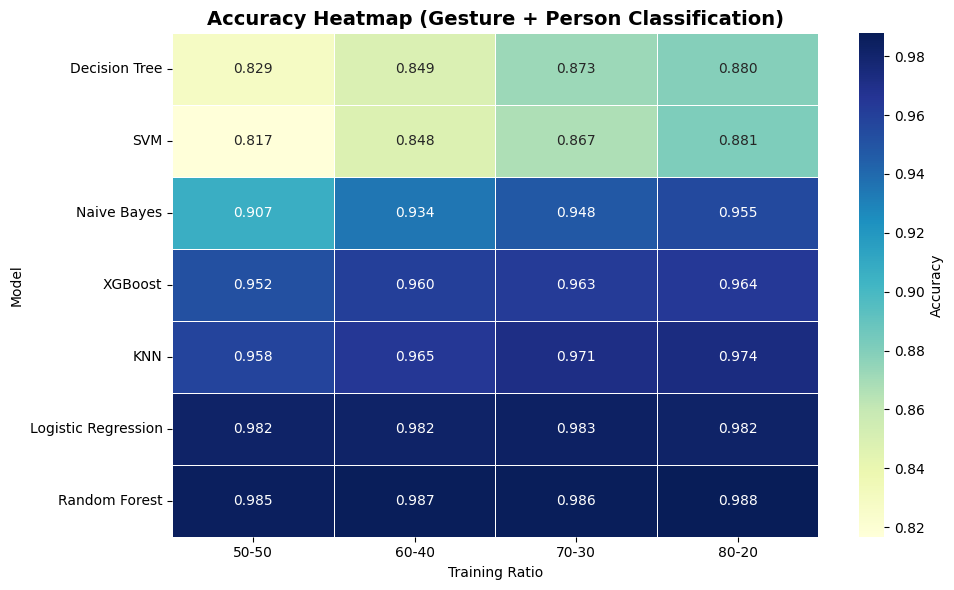

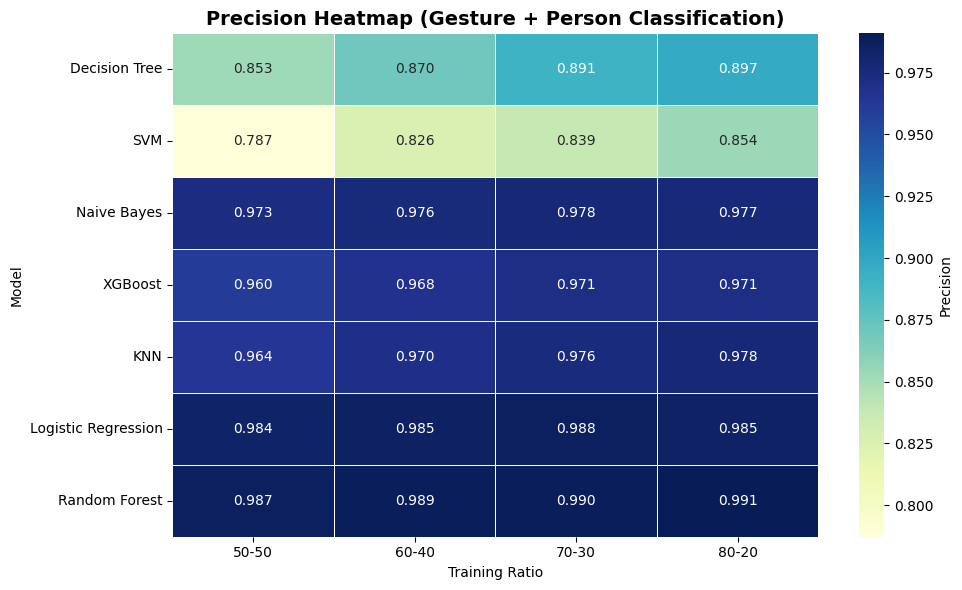

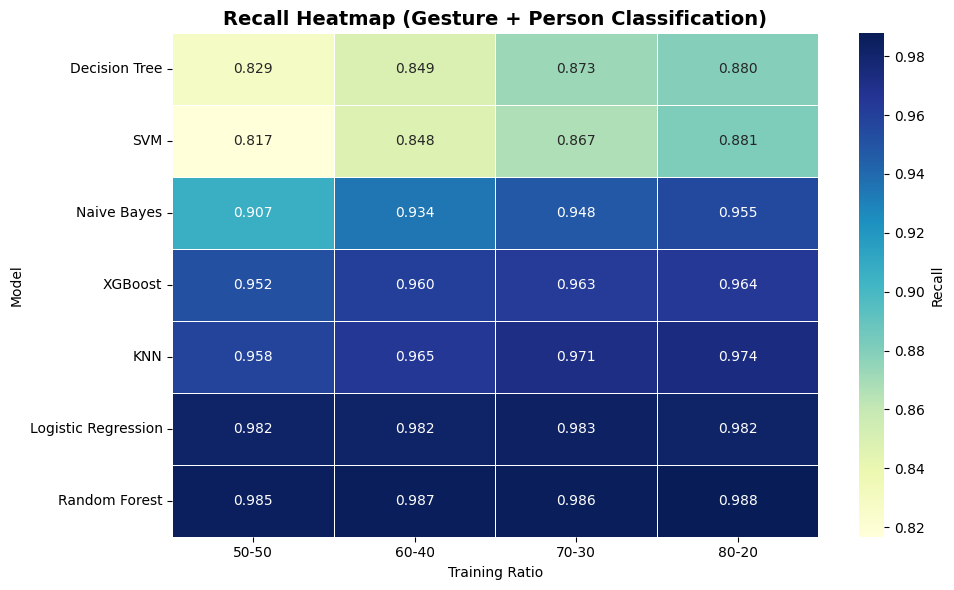

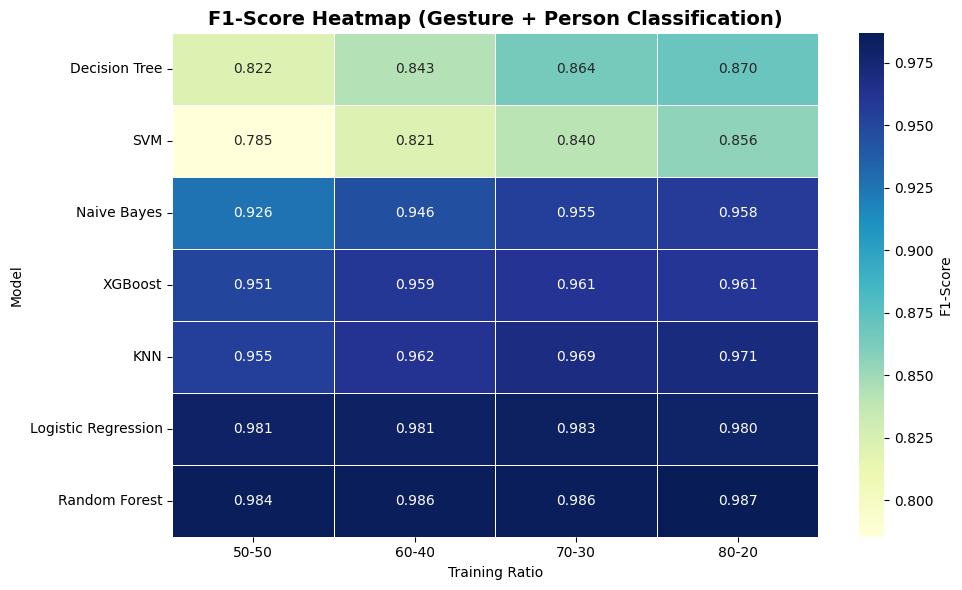

In [62]:
plot_heatmap(
    df_exp3,
    "Accuracy",
    "Accuracy Heatmap (Gesture + Person Classification)"
)

plot_heatmap(
    df_exp3,
    "Precision",
    "Precision Heatmap (Gesture + Person Classification)"
)

plot_heatmap(
    df_exp3,
    "Recall",
    "Recall Heatmap (Gesture + Person Classification)"
)

plot_heatmap(
    df_exp3,
    "F1-Score",
    "F1-Score Heatmap (Gesture + Person Classification)"
)


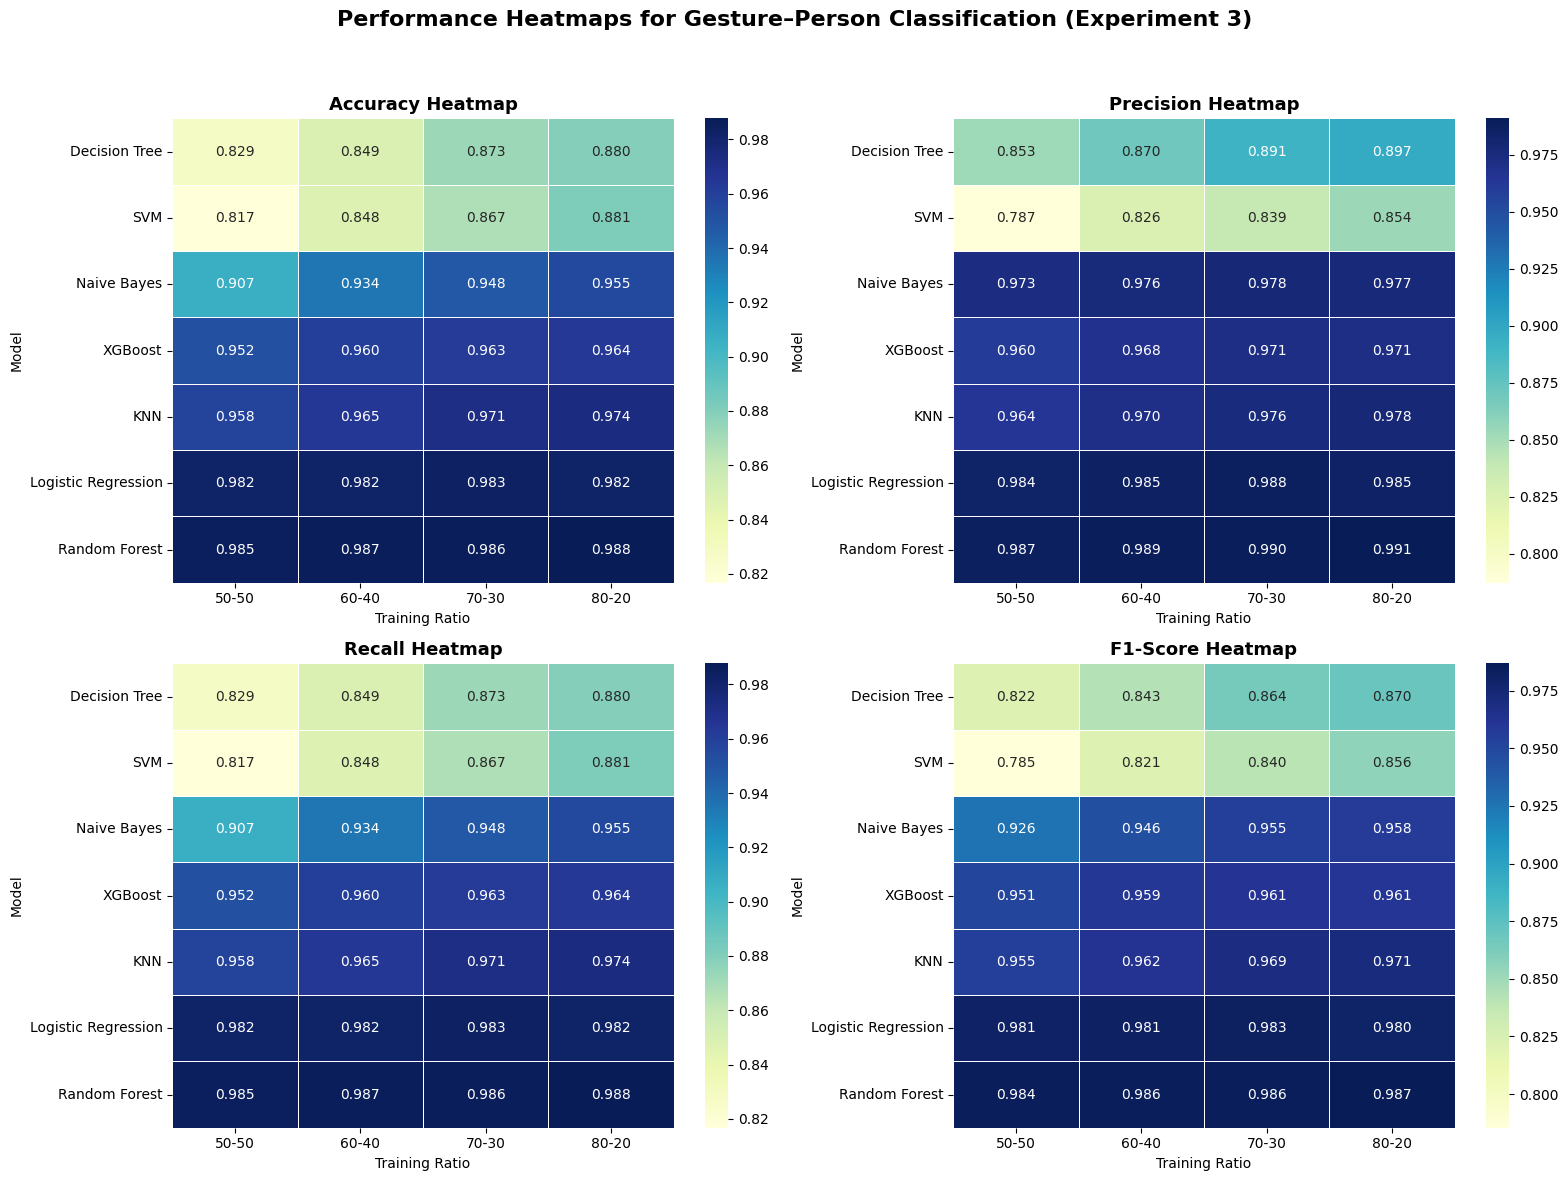

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
titles = [
    "Accuracy Heatmap",
    "Precision Heatmap",
    "Recall Heatmap",
    "F1-Score Heatmap"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    heatmap_data = df_exp3.pivot_table(
        index="Model",
        columns="Train Ratio",
        values=metric,
        aggfunc="mean"
    ).reindex(model_order)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        ax=axes[i],
        cbar=True
    )

    axes[i].set_title(titles[i], fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Training Ratio")
    axes[i].set_ylabel("Model")

plt.suptitle(
    "Performance Heatmaps for Gesture–Person Classification (Experiment 3)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
stat_summary = (
    df_exp3.groupby("Model")["Accuracy"]
    .agg(
        Mean_Accuracy="mean",
        Std_Deviation="std",
        Best_Accuracy="max",
        Worst_Accuracy="min"
    )
    .reindex(model_order)
    .reset_index()
)
stat_summary

,Model,Mean_Accuracy,Std_Deviation,Best_Accuracy,Worst_Accuracy
0,Decision Tree,0.857563,0.022246,0.888145,0.820513
1,SVM,0.853307,0.025287,0.887189,0.809032
2,Naive Bayes,0.936252,0.019966,0.960803,0.897053
3,XGBoost,0.959813,0.005898,0.971301,0.948335
4,KNN,0.966953,0.007202,0.978011,0.952928
5,Logistic Regression,0.982323,0.002941,0.990434,0.978967
6,Random Forest,0.986477,0.002502,0.991071,0.981248


In [65]:
stat_summary.iloc[:, 1:] = stat_summary.iloc[:, 1:].round(4)
stat_summary

,Model,Mean_Accuracy,Std_Deviation,Best_Accuracy,Worst_Accuracy
0,Decision Tree,0.8576,0.0222,0.8881,0.8205
1,SVM,0.8533,0.0253,0.8872,0.8090
2,Naive Bayes,0.9363,0.0200,0.9608,0.8971
3,XGBoost,0.9598,0.0059,0.9713,0.9483
4,KNN,0.9670,0.0072,0.9780,0.9529
5,Logistic Regression,0.9823,0.0029,0.9904,0.9790
6,Random Forest,0.9865,0.0025,0.9911,0.9812
